# Kaggle Playground Series S6E4 — Predicting Irrigation Need
## Exploratory Data Analysis

---

**Competition:** [PS S6E4 — Predicting Irrigation Need](https://www.kaggle.com/competitions/playground-series-s6e4)  
**Task:** Multiclass classification → `Low` / `Medium` / `High`  
**Metric:** Balanced Accuracy  
**Dataset:** 630,000 synthetic rows generated from [Irrigation Water Requirement Prediction Dataset](https://www.kaggle.com/datasets/miadul/irrigation-water-requirement-prediction-dataset)

---

## Table of Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Dataset Overview](#2-dataset-overview)
3. [Target Analysis](#3-target-analysis)
4. [Numerical Features — Distributions](#4-numerical-features--distributions)
5. [Categorical Features — Target Rates](#5-categorical-features--target-rates)
6. [Feature vs Target — KDE Analysis](#6-feature-vs-target--kde-analysis)
7. [Correlation Matrix](#7-correlation-matrix)
8. [Train vs Test Distribution Shift](#8-train-vs-test-distribution-shift)
9. [Original vs Synthetic Dataset](#9-original-vs-synthetic-dataset)
10. [Statistical Feature Importance](#10-statistical-feature-importance)
11. [EDA Summary & Feature Engineering Roadmap](#11-eda-summary--feature-engineering-roadmap)


---
## 1. Setup & Data Loading


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

RANDOM_STATE = 42
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [21]:
train = pd.read_csv(r'/Users/deonissx/Documents/Hackathons/kaggle-playground-irrigation-prediction/playground-series-s6e4/train.csv')
test = pd.read_csv(r'/Users/deonissx/Documents/Hackathons/kaggle-playground-irrigation-prediction/playground-series-s6e4/test.csv')
sample_submission = pd.read_csv(r'/Users/deonissx/Documents/Hackathons/kaggle-playground-irrigation-prediction/playground-series-s6e4/sample_submission.csv')

df = train.copy(deep = True)
df_test = test.copy(deep = True)

print(f'Train shape :  {train.shape}')
print(f'Test shape :  {test.shape}')

Train shape :  (630000, 21)
Test shape :  (270000, 20)


In [22]:
df.sample(3)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
31618,31618,Clay,6.460,55.490,0.840,1.410,23.910,83.620,1130.920,8.340,11.290,Rice,Sowing,Zaid,Rainfed,Groundwater,0.510,No,91.220,Central,Low
316297,316297,Silt,6.650,47.820,1.540,2.760,31.830,55.810,1639.540,8.260,9.360,Potato,Harvest,Rabi,Rainfed,Rainwater,3.140,Yes,81.800,North,Low
352214,352214,Loamy,7.940,62.820,0.800,0.110,24.210,79.140,2145.210,8.480,0.890,Cotton,Sowing,Rabi,Rainfed,River,11.980,Yes,108.620,South,Low


---
## 2. Dataset Overview

Quick structural check: shape, duplicates, memory, dtypes, missing values, unique counts.


In [23]:
def quick_eda(df):
    
    print('=' * 55)
    print(f'  Shape      : {df.shape[0]:,} rows x {df.shape[1]} columns')
    print(f'  Duplicates : {df.duplicated().sum()}')
    print(f'  Memory     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
    print('=' * 55)

    info = pd.DataFrame({
        'dtype'    : df.dtypes,
        'non-null' : df.count(),
        'missing'  : df.isnull().sum(),
        'missing%' : (df.isnull().mean() * 100).round(2),
        'unique'   : df.nunique()
    })
    return info

quick_eda(df)

  Shape      : 630,000 rows x 21 columns
  Duplicates : 0
  Memory     : 369.5 MB


,dtype,non-null,missing,missing%,unique
id,int64,630000,0,0.000,630000
Soil_Type,object,630000,0,0.000,4
Soil_pH,float64,630000,0,0.000,341
Soil_Moisture,float64,630000,0,0.000,5223
Organic_Carbon,float64,630000,0,0.000,131
Electrical_Conductivity,float64,630000,0,0.000,341
Temperature_C,float64,630000,0,0.000,2934
Humidity,float64,630000,0,0.000,6475
Rainfall_mm,float64,630000,0,0.000,19308
Sunlight_Hours,float64,630000,0,0.000,701


In [24]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'id']
print(num_cols)

train[num_cols].describe().round(2)

['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']


,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000
mean,6.480,37.300,0.920,1.740,27.000,61.560,1462.210,7.510,10.380,7.520,62.320
std,0.920,16.380,0.370,0.950,8.620,19.710,612.990,2.000,5.690,4.220,34.250
min,4.800,8.000,0.300,0.100,12.000,25.000,0.380,4.000,0.500,0.300,0.020
25%,5.690,23.340,0.610,0.930,19.520,45.390,954.570,5.760,5.280,3.880,33.140
50%,6.440,37.750,0.910,1.740,26.960,61.650,1467.160,7.580,10.480,7.380,61.150
75%,7.270,51.270,1.220,2.580,34.540,79.120,2054.280,9.250,15.430,11.140,92.690
max,8.200,64.990,1.600,3.500,42.000,94.990,2499.690,11.000,20.000,15.000,119.990


In [25]:
for col in ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region', 'Irrigation_Need']:
    print(f'{col}: {df[col].unique()}')

Soil_Type: ['Loamy' 'Clay' 'Sandy' 'Silt']
Crop_Type: ['Sugarcane' 'Wheat' 'Rice' 'Potato' 'Cotton' 'Maize']
Crop_Growth_Stage: ['Sowing' 'Vegetative' 'Flowering' 'Harvest']
Season: ['Zaid' 'Kharif' 'Rabi']
Irrigation_Type: ['Drip' 'Rainfed' 'Sprinkler' 'Canal']
Water_Source: ['Rainwater' 'River' 'Reservoir' 'Groundwater']
Mulching_Used: ['No' 'Yes']
Region: ['East' 'South' 'North' 'West' 'Central']
Irrigation_Need: ['Low' 'Medium' 'High']


**Key observations:**
- ✅ No missing values across all 21 columns
- ⚠️ `Organic_Carbon` — only **131 unique values** out of 630k rows → likely discrete in original dataset
- ⚠️ `Soil_pH` and `Electrical_Conductivity` — both exactly **341 unique values** → suspiciously symmetric
- ⚠️ `Sunlight_Hours` — **701 unique values** → discrete peaks visible in histograms
- → These three columns are strong candidates for **Snap Features** (mapping back to original discrete values)


---
## 3. Target Analysis

Target: `Irrigation_Need` with three ordinal classes: `Low=0`, `Medium=1`, `High=2`


In [26]:
df['Irrigation_Need'] = df['Irrigation_Need'].astype(str).str.strip()

target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}


df['Irrigation_Need'] = df['Irrigation_Need'].map(target_mapping)


if df['Irrigation_Need'].isna().any():
    print("Gaps have appeared. Unique values ​​in the original were:", train['Irrigation_Need'].unique())
else:
    print("Success! Now the data type: ", df['Irrigation_Need'].dtype)

Success! Now the data type:  int64


In [27]:
print(df['Irrigation_Need'].value_counts())
print()
print(df['Irrigation_Need'].value_counts(normalize=True) * 100)

Irrigation_Need
0    369917
1    239074
2     21009
Name: count, dtype: int64

Irrigation_Need
0   58.717
1   37.948
2    3.335
Name: proportion, dtype: float64


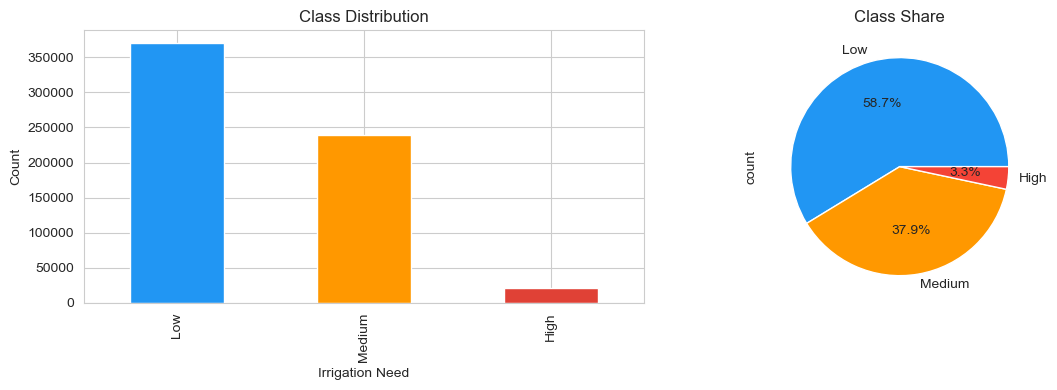

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train['Irrigation_Need'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2196F3', '#FF9800', "#E04136"],
    title='Class Distribution'
)
axes[0].set_xlabel('Irrigation Need')
axes[0].set_ylabel('Count')

train['Irrigation_Need'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#2196F3', '#FF9800', '#F44336'],
    title='Class Share'
)
plt.tight_layout()
plt.show()

**Critical finding — severe class imbalance:**

| Class | Count | Share |
|-------|-------|-------|
| Low | 369,917 | 58.7% |
| Medium | 239,074 | 37.9% |
| **High** | **21,009** | **3.3%** |

`High` is **18× rarer** than `Low`. Without correction, a model will learn to ignore it entirely.  
Since the metric is **Balanced Accuracy**, this will be heavily penalized.  
→ **Solution in ML phase:** `class_weight='balanced'`


---
## 4. Numerical Features — Distributions


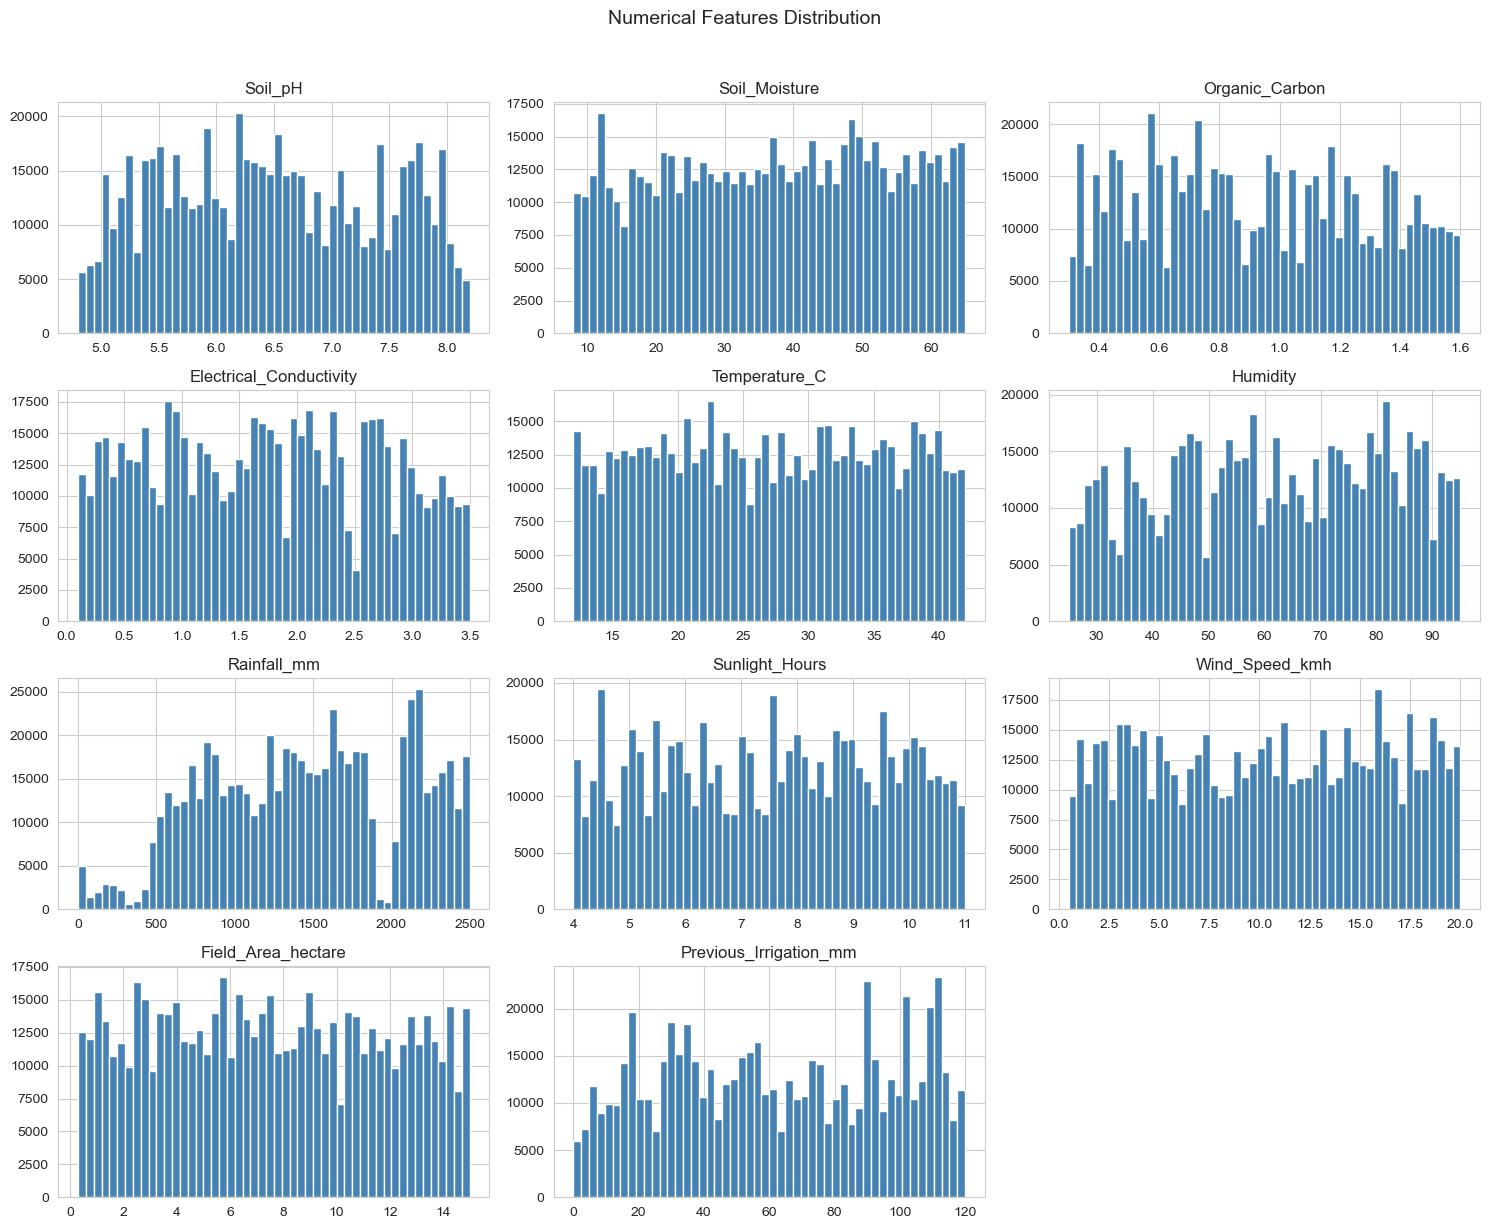

In [29]:
df[num_cols].hist(bins=50, figsize=(15, 12), color='steelblue', edgecolor='white')
plt.suptitle('Numerical Features Distribution', y=1.02, fontsize=14)

plt.tight_layout()
plt.show()

**Notable patterns:**
- `Rainfall_mm` — large spike near zero in synthetic data (not present in original) → synthetic generator artifact → candidate for binary flag `is_dry`
- `Sunlight_Hours` — clear discrete peaks confirm the original was integer-rounded → Snap Features applicable
- `Previous_Irrigation_mm` — spike at maximum (~120mm), values are capped → ceiling artifact from original dataset
- `Wind_Speed_kmh` — spike near zero, similar to Rainfall pattern


---
## 5. Categorical Features — Target Rates

Red dashed line = overall dataset mean. Bars to the right = higher irrigation need than average.


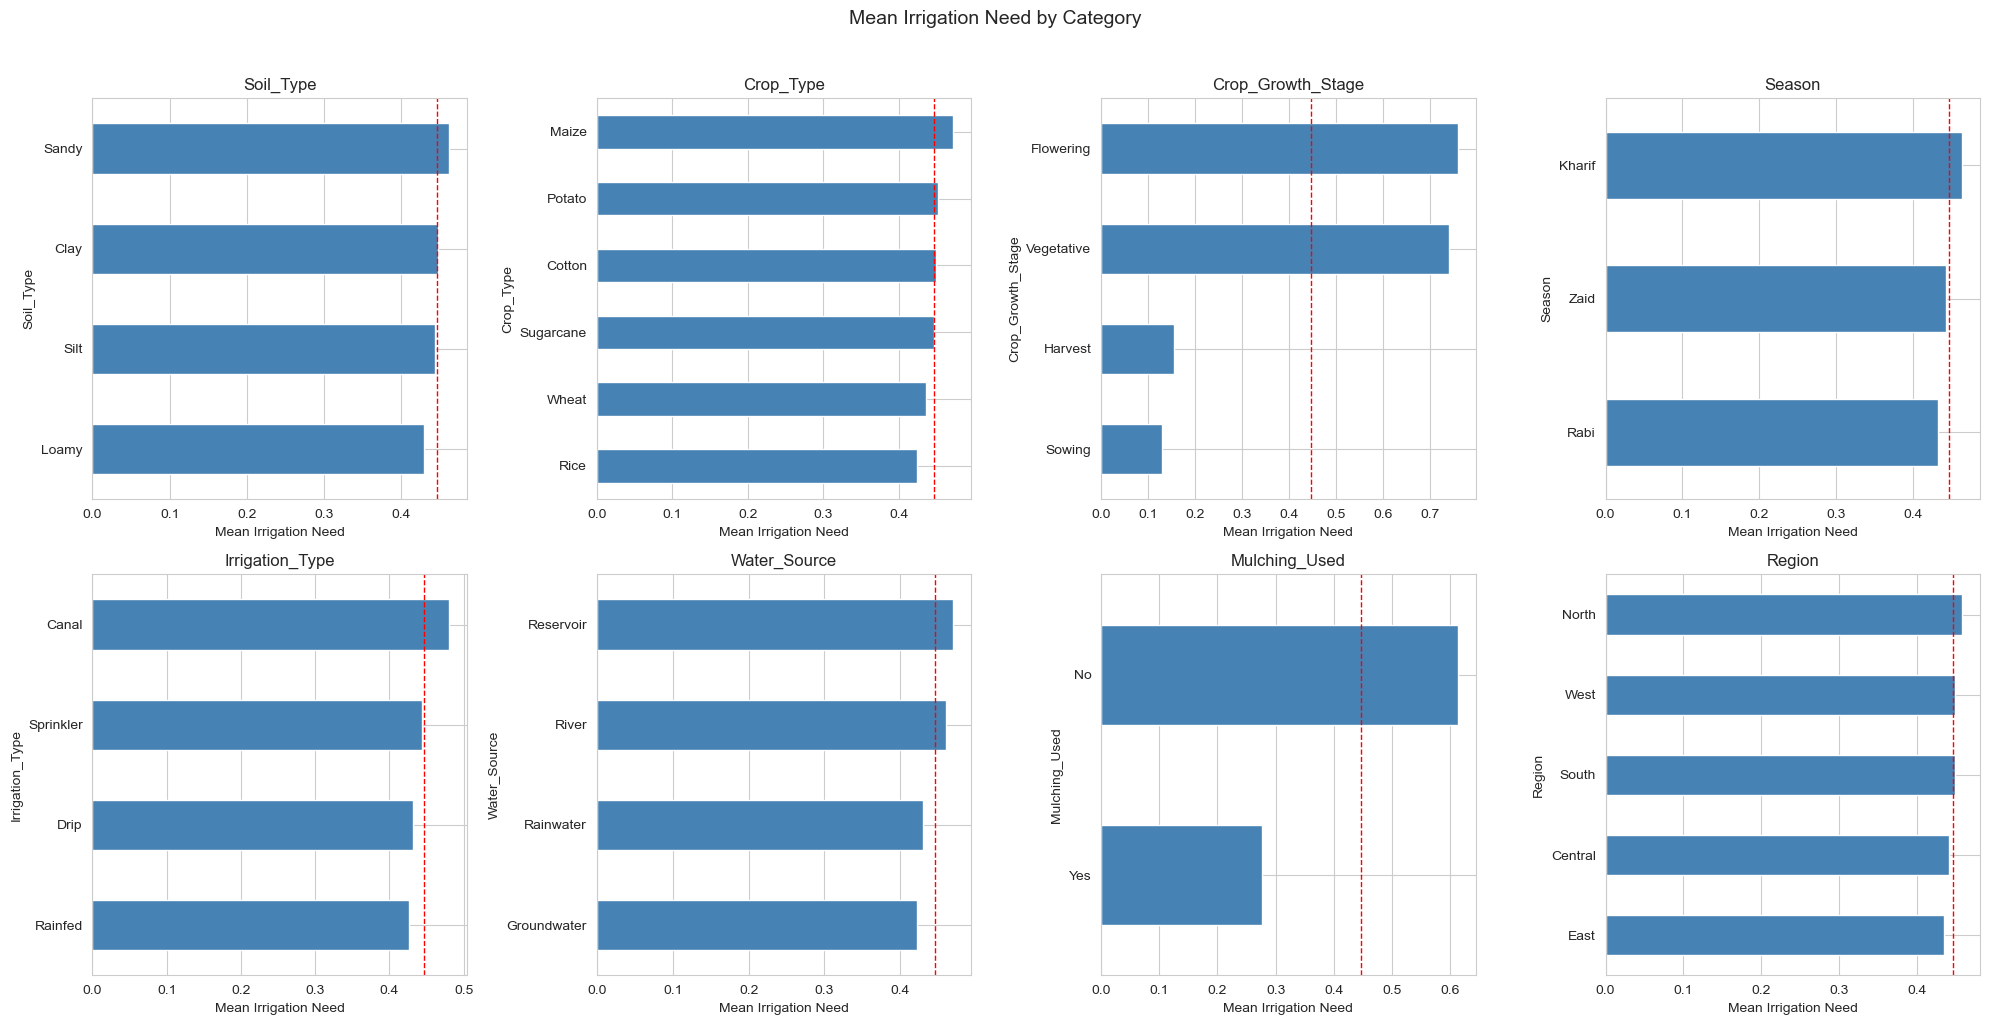

In [30]:
cat_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 
            'Season', 'Irrigation_Type', 'Water_Source', 
            'Mulching_Used', 'Region']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['Irrigation_Need'].mean().sort_values()
    rate.plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].axvline(df['Irrigation_Need'].mean(), 
                   color='red', linestyle='--', linewidth=1)
    axes[i].set_title(col)
    axes[i].set_xlabel('Mean Irrigation Need')

plt.suptitle('Mean Irrigation Need by Category', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Key findings:**

| Feature | Signal | Observation |
|---------|--------|-------------|
| `Mulching_Used` | 🔴 Strong | `No` → much higher need; mulch retains soil moisture |
| `Crop_Growth_Stage` | 🔴 Strong | `Flowering`/`Vegetative` → high need; `Sowing`/`Harvest` → low |
| `Season` | 🟡 Medium | `Kharif` (summer) → higher; `Rabi` (winter) → lower |
| `Irrigation_Type` | 🟡 Medium | `Drip`/`Rainfed` → lower (efficient or rain-dependent) |
| `Region`, `Soil_Type` | ⚪ Weak | Bars cluster near mean — low standalone signal |


---
## 6. Feature vs Target — KDE Analysis

KDE (Kernel Density Estimation) shows the smoothed distribution of each feature **per class**.  
Curves that diverge = strong signal. Curves that overlap = weak signal.  
`density=True` normalizes all classes to the same scale despite class imbalance.


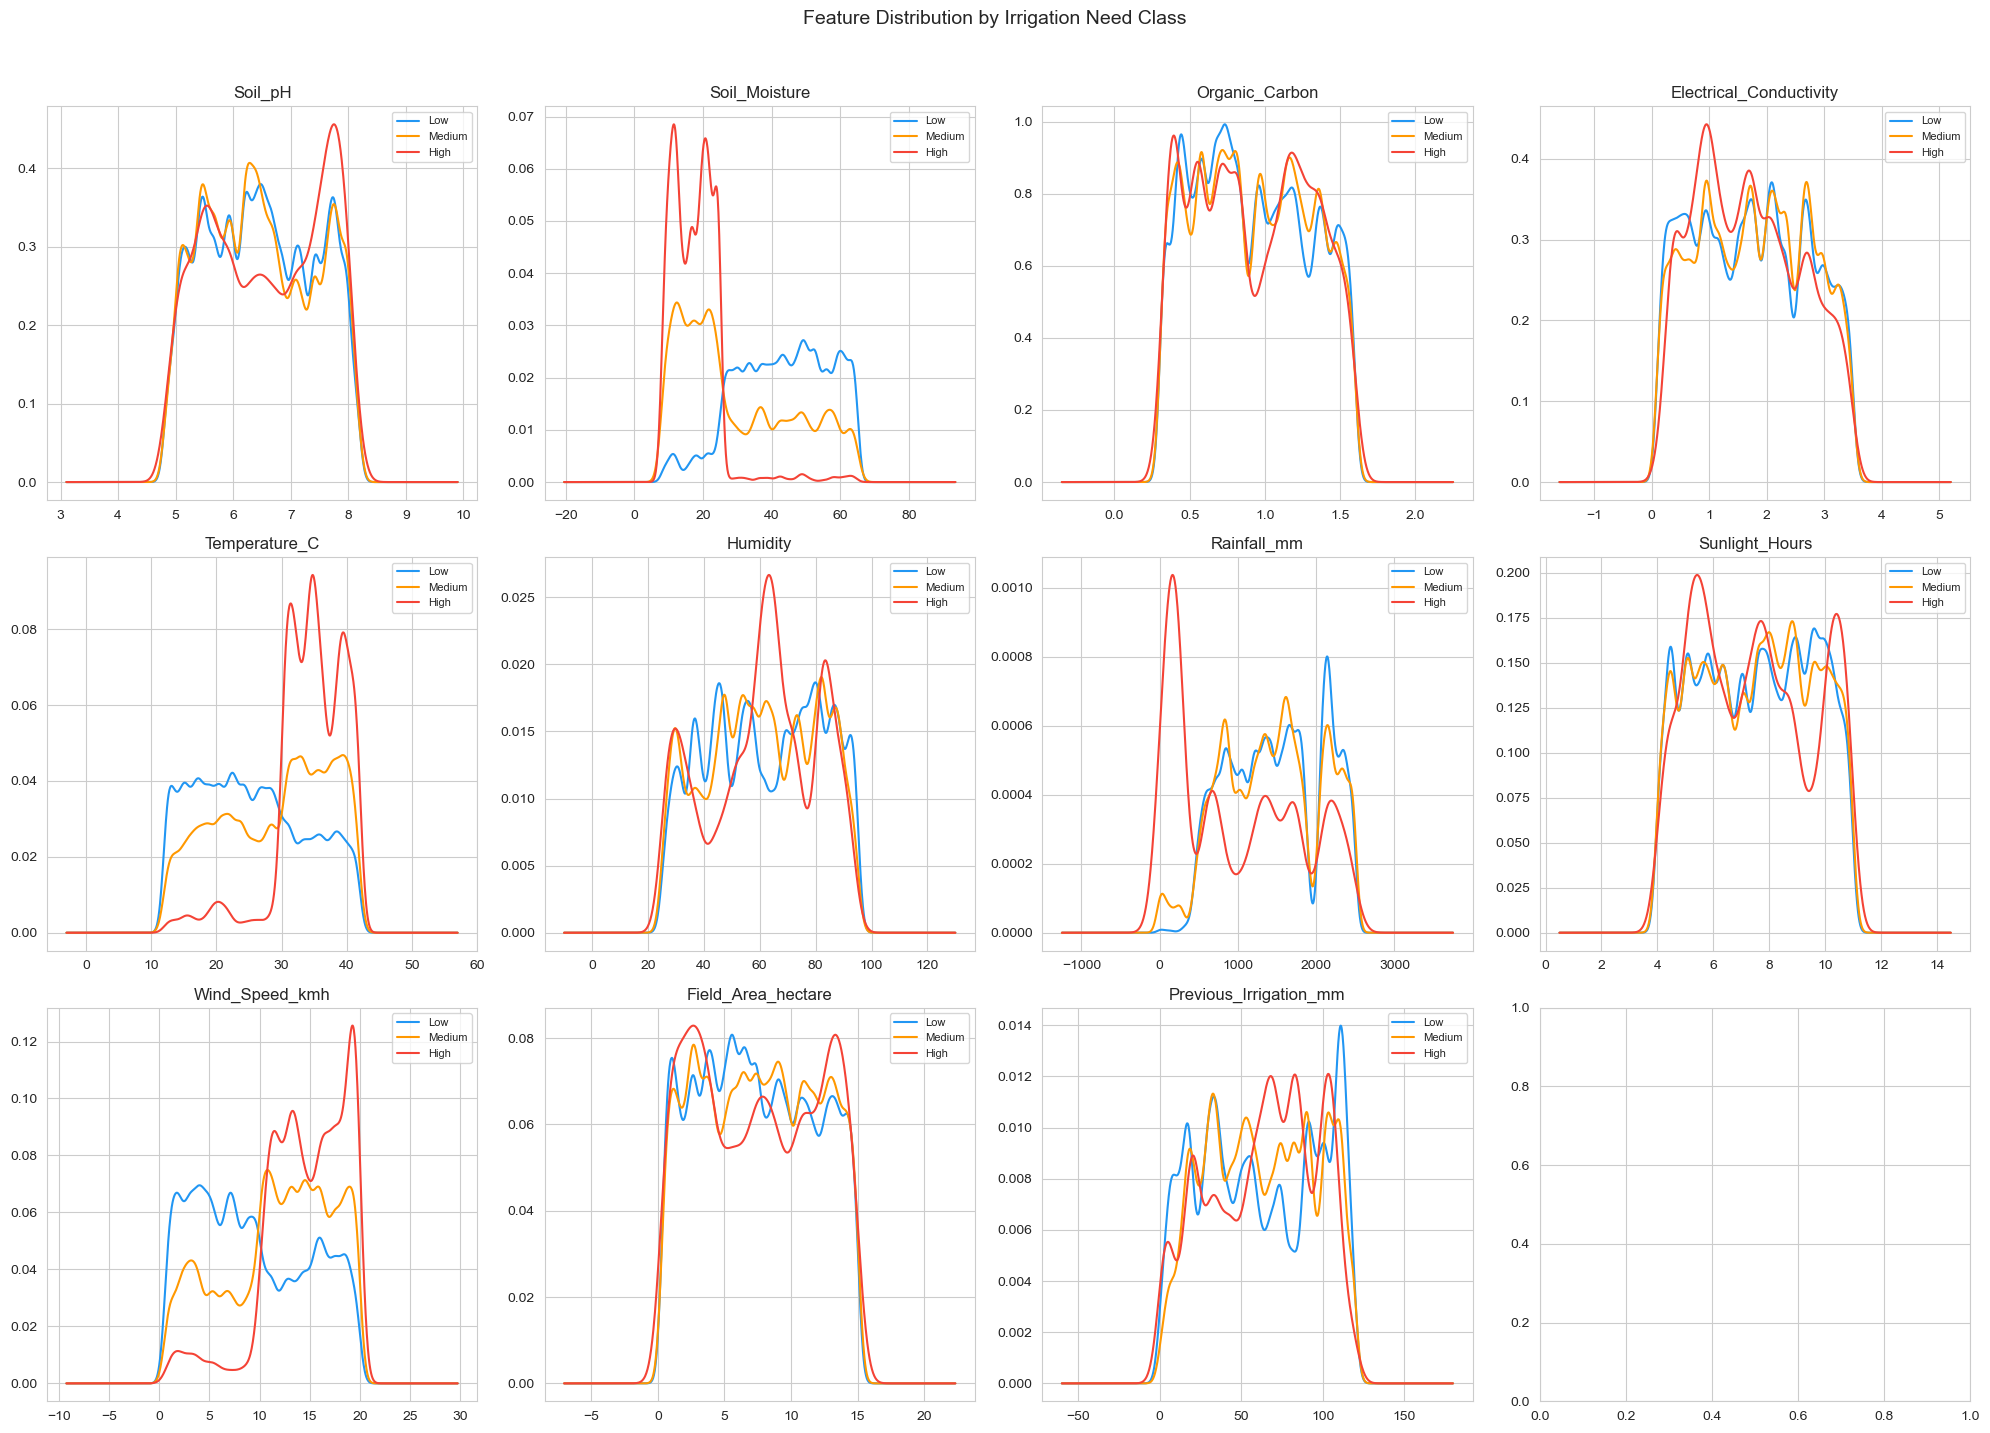

In [31]:
import scipy

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

colors = {0: '#2196F3', 1: '#FF9800', 2: '#F44336'}
labels = {0: 'Low', 1: 'Medium', 2: 'High'}

for i, col in enumerate(num_cols):
    for cls in [0, 1, 2]:
        subset = df[df['Irrigation_Need'] == cls][col]
        subset.plot(kind='kde', ax=axes[i],
                   color=colors[cls], label=labels[cls], linewidth=1.5)
        
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('')

plt.suptitle('Feature Distribution by Irrigation Need Class', y=1.02, fontsize=14)

plt.tight_layout()
plt.show()

**Signal strength by feature:**

| Strength | Features |
|----------|----------|
| 🔴 Strong | `Soil_Moisture`, `Temperature_C`, `Wind_Speed_kmh` |
| 🟡 Medium | `Humidity`, `Rainfall_mm` |
| ⚪ Weak | `Soil_pH`, `Sunlight_Hours`, `Organic_Carbon`, `EC`, `Field_Area`, `Previous_Irrigation` |

`Soil_Moisture`: `High` class concentrates at low moisture (10–25%), `Low` class at high moisture (40–65%) — strongest separator.


---
## 7. Correlation Matrix

Pearson correlation between all numerical features. Values near 0 = independent features.


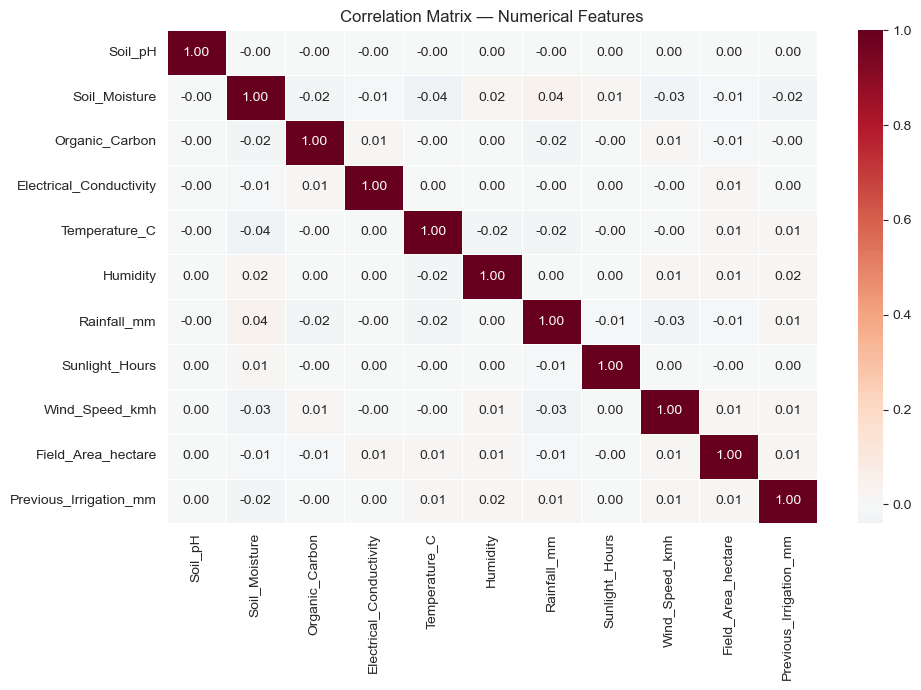

In [32]:
corr = df[num_cols].corr().round(2)

plt.figure(figsize=(10, 7))

sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix — Numerical Features')

plt.tight_layout()
plt.show()

**Finding:** All inter-feature correlations are near zero (max = 0.04).  
→ No multicollinearity. Each feature carries **independent signal**.  
→ No features need to be dropped due to redundancy.


---
## 8. Train vs Test Distribution Shift

Kolmogorov-Smirnov test compares distributions of each feature between train and test sets.  
`p < 0.05` → statistically significant shift → model may underperform on test vs CV.


In [33]:
from scipy.stats import ks_2samp

print(f"{'Feature':<30} {'KS stat':>10} {'p-value':>10} {'Status':>8}")
print("-" * 60)

for col in num_cols:
    stat, p = ks_2samp(df[col], test[col])
    status = "⚠️ SHIFT" if p < 0.05 else "✅ OK"
    print(f"{col:<30} {stat:>10.4f} {p:>10.4f} {status:>8}")

Feature                           KS stat    p-value   Status
------------------------------------------------------------
Soil_pH                            0.0013     0.9224     ✅ OK
Soil_Moisture                      0.0015     0.8013     ✅ OK
Organic_Carbon                     0.0017     0.6632     ✅ OK
Electrical_Conductivity            0.0019     0.5040     ✅ OK
Temperature_C                      0.0020     0.4186     ✅ OK
Humidity                           0.0024     0.2135     ✅ OK
Rainfall_mm                        0.0027     0.1203     ✅ OK
Sunlight_Hours                     0.0018     0.5634     ✅ OK
Wind_Speed_kmh                     0.0020     0.4438     ✅ OK
Field_Area_hectare                 0.0025     0.2050     ✅ OK
Previous_Irrigation_mm             0.0018     0.5420     ✅ OK


**Result: All features ✅ — no distribution shift detected.**  

Expected for Kaggle Playground: both train and test are generated by the **same synthetic model** from the same original dataset. They are statistically identical samples.


---
## 9. Original vs Synthetic Dataset

The synthetic data was generated from a real dataset of 10,000 rows.  
Comparing distributions reveals generator artifacts and confirms which features to apply **Snap Features** on.


In [34]:
original = pd.read_csv('/Users/deonissx/Documents/Hackathons/kaggle-playground-irrigation-prediction/playground-series-s6e4/irrigation_prediction.csv')
print(original.shape)
print(original.columns.tolist())
print(original.head(3))

(10000, 20)
['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need']
  Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  Electrical_Conductivity  \
0      Clay    6.140         36.480           0.420                    2.170   
1      Silt    6.410         50.560           0.380                    0.230   
2     Sandy    7.710         40.070           1.090                    2.180   

   Temperature_C  Humidity  Rainfall_mm  Sunlight_Hours  Wind_Speed_kmh  \
0         21.900    31.190     1167.700           4.010           1.970   
1         36.500    26.010      831.280          10.720          16.820   
2         41.830    76.410     1844.450           7.750          19.030   

  Crop_Type Crop_Growth_St

In [35]:
print("=== Target Distribution ===")
print("\nOriginal:")
print(original['Irrigation_Need'].value_counts())
print(original['Irrigation_Need'].value_counts(normalize=True).mul(100).round(1))

print("\nSynthetic train:")
print(df['Irrigation_Need'].value_counts())
print(df['Irrigation_Need'].value_counts(normalize=True).mul(100).round(1))

=== Target Distribution ===

Original:
Irrigation_Need
Low       5864
Medium    3800
High       336
Name: count, dtype: int64
Irrigation_Need
Low      58.600
Medium   38.000
High      3.400
Name: proportion, dtype: float64

Synthetic train:
Irrigation_Need
0    369917
1    239074
2     21009
Name: count, dtype: int64
Irrigation_Need
0   58.700
1   37.900
2    3.300
Name: proportion, dtype: float64


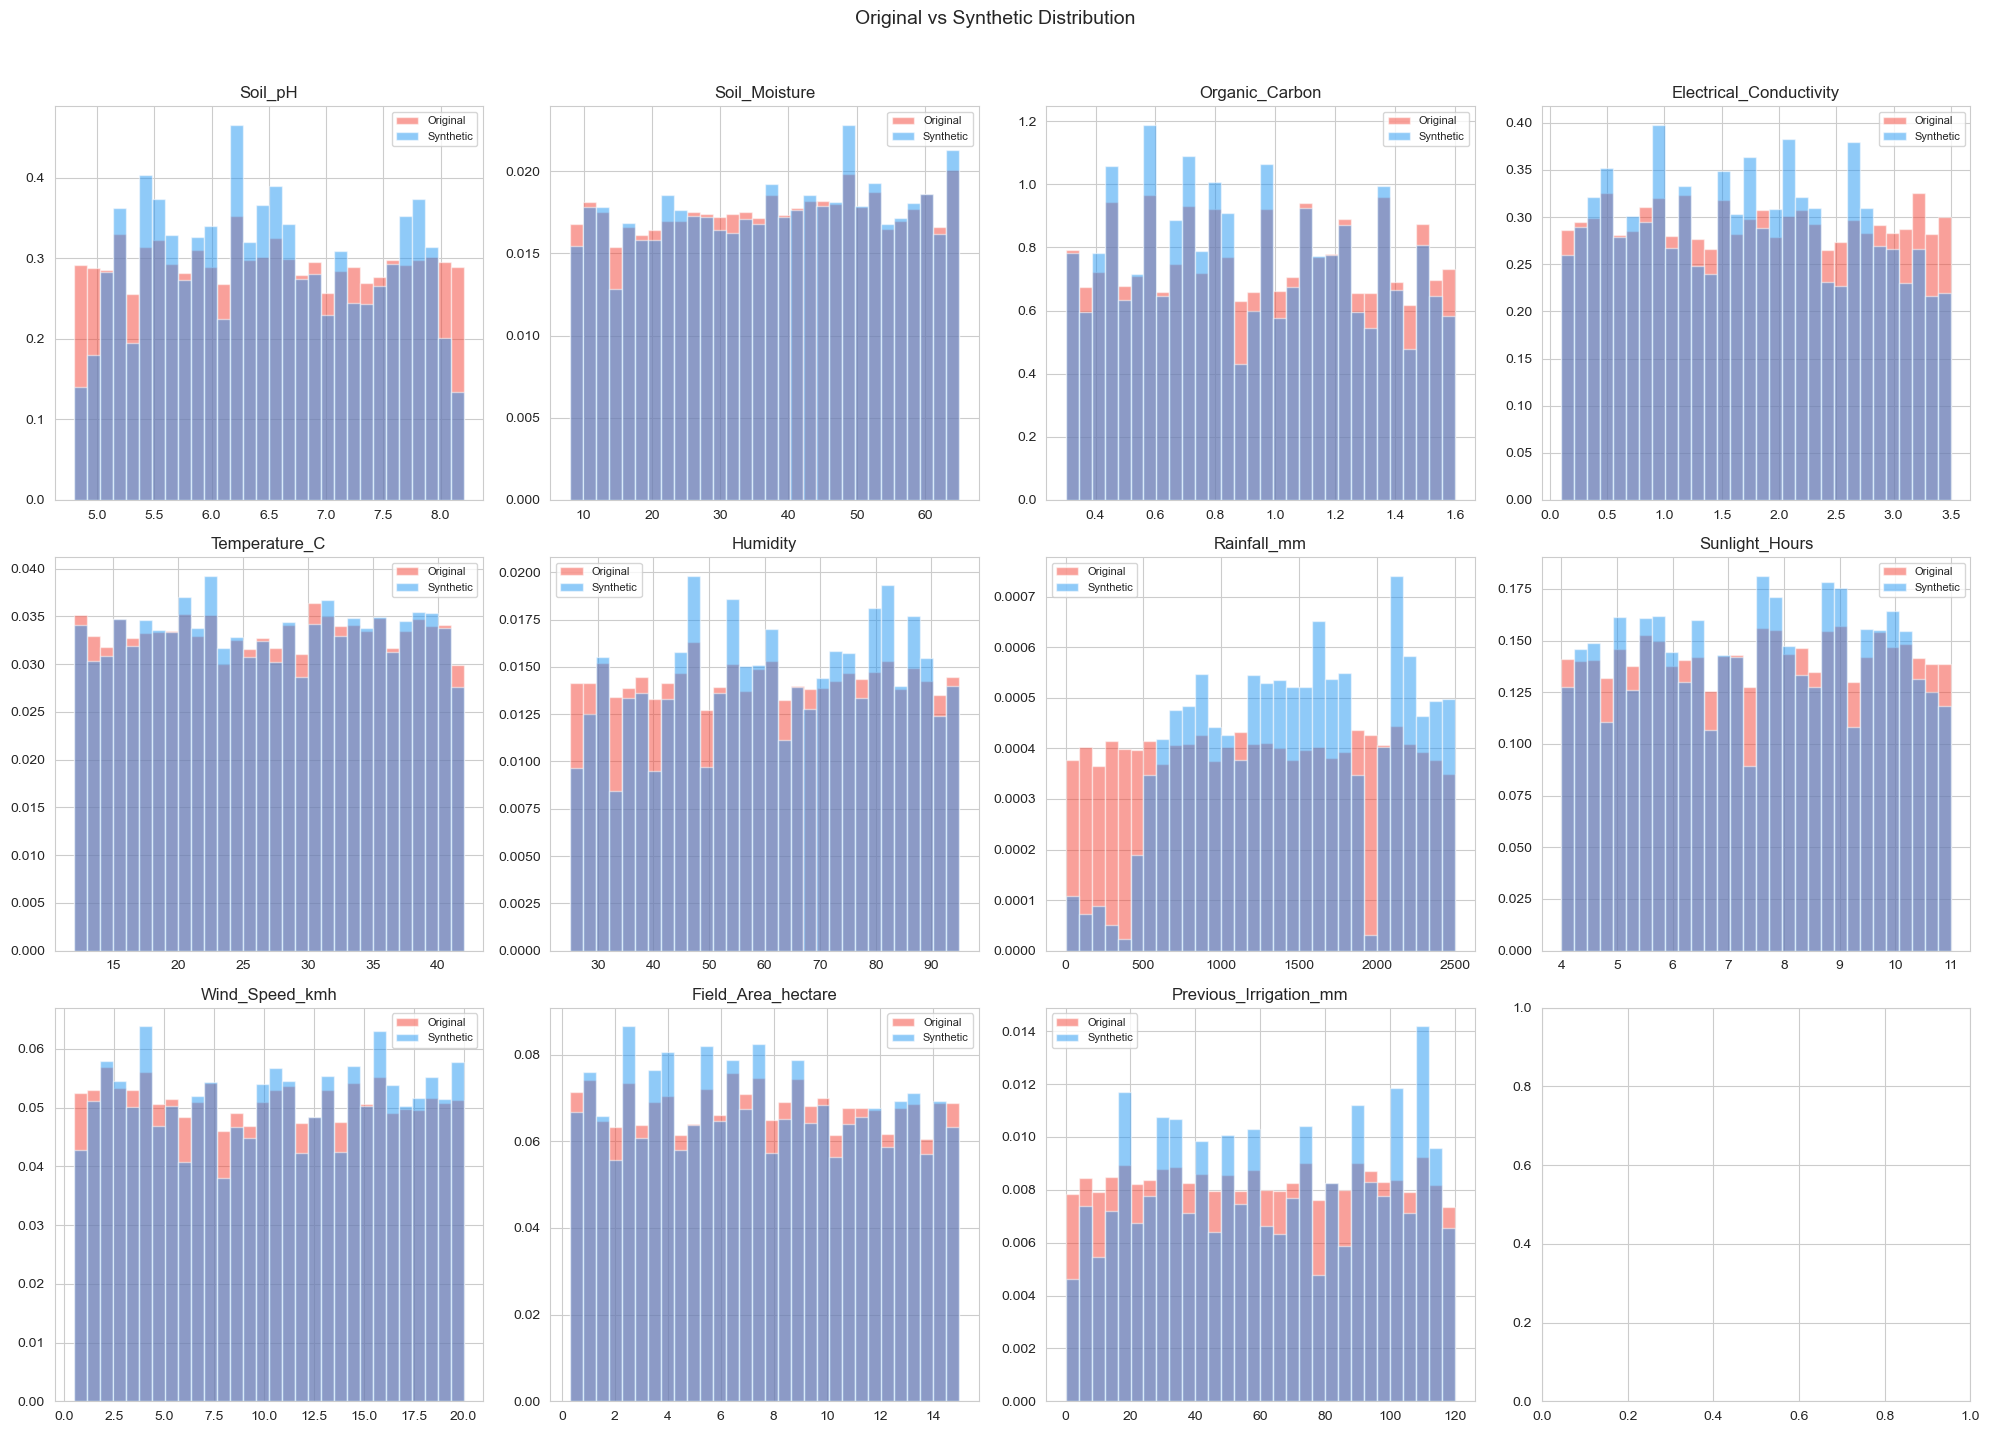

In [36]:
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(original[col], bins=30, alpha=0.5, 
                color='#F44336', label='Original', density=True)
    axes[i].hist(df[col], bins=30, alpha=0.5, 
                color='#2196F3', label='Synthetic', density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Original vs Synthetic Distribution', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Findings:**
- Target class proportions are **nearly identical** between original and synthetic → imbalance is real, not an artifact
- Most feature distributions match well → generator did a good job overall
- `Rainfall_mm` — spike near zero exists **only in synthetic**, not in original → confirmed artifact
- Original dataset has only 10,000 rows (synthetic = 63× larger) → original can be used as additional training data


---
## 10. Statistical Feature Importance

### 10.1 Mutual Information — Numerical Features
Captures both **linear and non-linear** relationships with the target.  
Unlike Pearson correlation, it is not limited to monotonic dependencies.


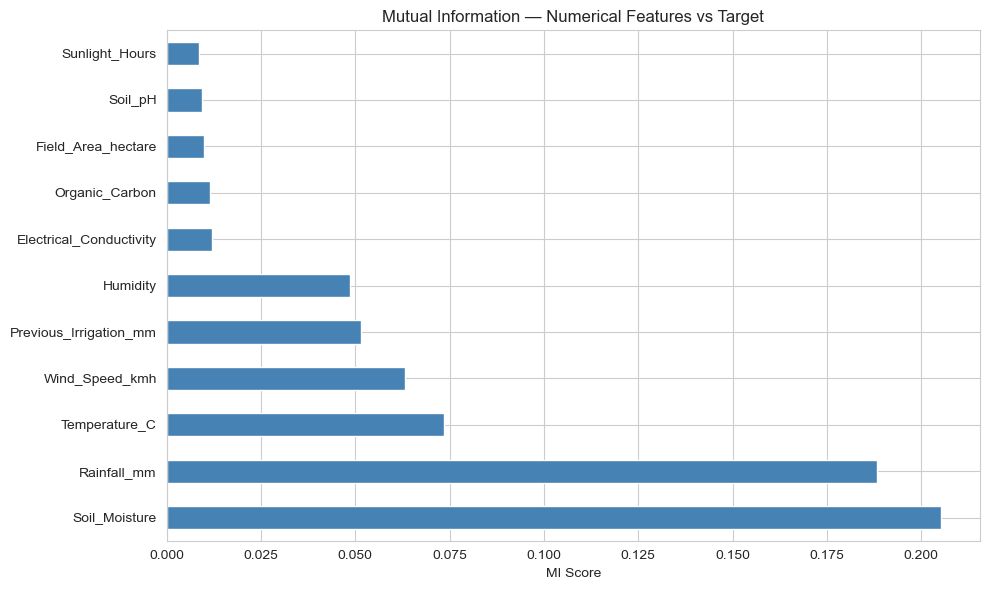

Soil_Moisture             0.205
Rainfall_mm               0.188
Temperature_C             0.073
Wind_Speed_kmh            0.063
Previous_Irrigation_mm    0.052
Humidity                  0.049
Electrical_Conductivity   0.012
Organic_Carbon            0.012
Field_Area_hectare        0.010
Soil_pH                   0.009
Sunlight_Hours            0.008
dtype: float64


In [37]:

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(df['Irrigation_Need'])

X_num = df[num_cols].copy()

mi = mutual_info_classif(X_num, y_encoded, random_state=42)
mi_series = pd.Series(mi, index=X_num.columns).sort_values(ascending=False)

mi_series.plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Mutual Information — Numerical Features vs Target')
plt.xlabel('MI Score')
plt.tight_layout()
plt.show()
print(mi_series)

### 10.2 Chi-Squared Test — Categorical Features
Measures statistical association between each categorical feature and the target.  
Higher score = stronger dependency.


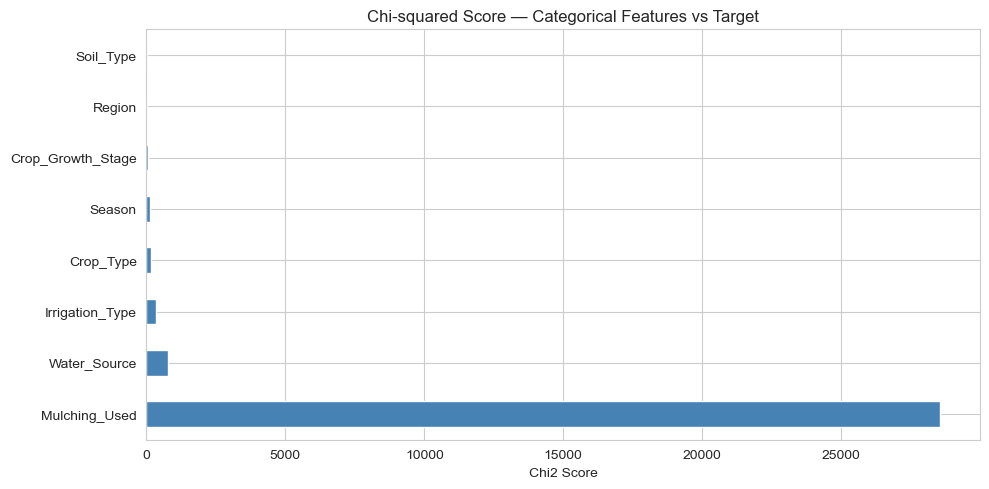

Mulching_Used       28569.630
Water_Source          791.596
Irrigation_Type       351.852
Crop_Type             168.033
Season                119.423
Crop_Growth_Stage      58.136
Region                 33.798
Soil_Type              22.256
dtype: float64


In [38]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

cat_cols_list = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage',
                 'Season', 'Irrigation_Type', 'Water_Source',
                 'Mulching_Used', 'Region']

le = LabelEncoder()
X_cat = df[cat_cols_list].apply(le.fit_transform)

chi2_scores, p_values = chi2(X_cat, y_encoded)
chi2_series = pd.Series(chi2_scores, index=cat_cols_list).sort_values(ascending=False)

chi2_series.plot(kind='barh', figsize=(10, 5), color='steelblue')
plt.title('Chi-squared Score — Categorical Features vs Target')
plt.xlabel('Chi2 Score')
plt.tight_layout()
plt.show()
print(chi2_series)

**Consolidated feature ranking:**

**Numerical (by MI score):**

| Rank | Feature | MI Score | Notes |
|------|---------|----------|-------|
| 1 | `Soil_Moisture` | 0.205 | Strongest predictor overall |
| 2 | `Rainfall_mm` | 0.188 | Non-linear signal; Pearson was only -0.11 |
| 3 | `Temperature_C` | 0.073 | |
| 4 | `Wind_Speed_kmh` | 0.063 | |
| 5 | `Previous_Irrigation_mm` | 0.052 | |
| 6 | `Humidity` | 0.049 | |
| 7–11 | Rest | <0.015 | Weak individually |

**Categorical (by Chi2 score):**

| Rank | Feature | Chi2 Score |
|------|---------|-----------|
| 1 | `Mulching_Used` | 28,569 |
| 2 | `Water_Source` | 791 |
| 3 | `Irrigation_Type` | 351 |
| 4 | `Crop_Type` | 168 |
| 5 | `Season` | 119 |
| 6 | `Crop_Growth_Stage` | 58 |
| 7 | `Region` | 33 |
| 8 | `Soil_Type` | 22 |


---
## 11. EDA Summary & Feature Engineering Roadmap

### Key Takeaways

**1. Severe class imbalance requires explicit handling**  
`High` class = 3.3% (21k rows). Balanced Accuracy metric will punish ignoring it.  
→ Use `class_weight='balanced'` in all models.

**2. Two numerical features dominate**  
`Soil_Moisture` (MI=0.205) and `Rainfall_mm` (MI=0.188) are the strongest predictors.  
Feature engineering should prioritize interactions involving these two.

**3. `Mulching_Used` is the single most powerful categorical feature**  
Chi2=28,569 — orders of magnitude above the second feature.  
One binary column explains more variance than all other categoricals combined.

---

### Feature Engineering Roadmap

| Priority | Feature Idea | Type | Based On |
|----------|-------------|------|----------|
| 🔴 High | `is_dry = 1 if Rainfall_mm < threshold` | Binary flag | Rainfall spike artifact |
| 🔴 High | Snap Features for `Organic_Carbon`, `Soil_pH`, `Electrical_Conductivity`, `Sunlight_Hours` | Snap | Low unique counts |
| 🟡 Medium | `Temperature_C × Wind_Speed_kmh` | Interaction | Both strong, independent |
| 🟡 Medium | `Soil_Moisture × Rainfall_mm` | Interaction | Two strongest features |
| 🟡 Medium | GroupBy mean target: `Crop_Type + Season` | Aggregate | Season signal |
| 🟡 Medium | GroupBy mean target: `Region + Season` | Aggregate | Regional climate |
| ⚪ Low | Digit/decimal extraction on synthetic floats | Snap noise | Playground artifact |


## Feature Engineering

In [39]:
from scipy.spatial import cKDTree

snap_cols = ['Organic_Carbon', 'Soil_pH', 'Electrical_Conductivity', 'Sunlight_Hours']

for col in snap_cols:
    orig_vals = original[col].unique()
    tree = cKDTree(orig_vals.reshape(-1, 1))
    _, idx = tree.query(df[col].values.reshape(-1, 1))
    df[f'{col}_snap'] = orig_vals[idx]
    df[f'{col}_snap_diff'] = df[col] - df[f'{col}_snap']

# Check result
print(df[['Organic_Carbon', 'Organic_Carbon_snap', 'Organic_Carbon_snap_diff']].head(10))

   Organic_Carbon  Organic_Carbon_snap  Organic_Carbon_snap_diff
0           1.010                1.010                     0.000
1           0.440                0.440                     0.000
2           0.810                0.810                     0.000
3           1.330                1.330                     0.000
4           0.380                0.380                     0.000
5           1.280                1.280                     0.000
6           1.440                1.440                     0.000
7           0.380                0.380                     0.000
8           0.900                0.900                     0.000
9           0.580                0.580                     0.000


In [40]:
for col in snap_cols:
    diff_col = f'{col}_snap_diff'
    non_zero = (df[diff_col] != 0).sum()
    print(f"{col}: non-zero diffs = {non_zero} ({non_zero/len(df)*100:.1f}%)")
    

Organic_Carbon: non-zero diffs = 0 (0.0%)
Soil_pH: non-zero diffs = 0 (0.0%)
Electrical_Conductivity: non-zero diffs = 0 (0.0%)
Sunlight_Hours: non-zero diffs = 0 (0.0%)


In [41]:
# 1. Binary flag: dry period
df['is_dry'] = (df['Rainfall_mm'] < 500).astype(int)
test['is_dry'] = (test['Rainfall_mm'] < 500).astype(int)

# Check: how many records flagged and target rate
print(df.groupby('is_dry')['Irrigation_Need'].value_counts(normalize=True).round(3))

is_dry  Irrigation_Need
0       0                 0.601
        1                 0.377
        2                 0.022
1       1                 0.425
        0                 0.288
        2                 0.287
Name: proportion, dtype: float64


In [42]:
# 2. Temperature × Wind Speed — оба сушат почву, комбинация усиливает эффект
df['Temp_x_Wind'] = df['Temperature_C'] * df['Wind_Speed_kmh']
test['Temp_x_Wind'] = test['Temperature_C'] * test['Wind_Speed_kmh']

# 3. Soil Moisture × Rainfall — два сильнейших предиктора
df['Moisture_x_Rain'] = df['Soil_Moisture'] * df['Rainfall_mm']
test['Moisture_x_Rain'] = test['Soil_Moisture'] * test['Rainfall_mm']

# Check distributions by class
for col in ['Temp_x_Wind', 'Moisture_x_Rain']:
    print(f"\n{col}:")
    print(df.groupby('Irrigation_Need')[col].mean().round(2))


Temp_x_Wind:
Irrigation_Need
0   231.880
1   334.570
2   506.870
Name: Temp_x_Wind, dtype: float64

Moisture_x_Rain:
Irrigation_Need
0   65004.520
1   42850.460
2   16902.800
Name: Moisture_x_Rain, dtype: float64


In [43]:
# 4. GroupBy aggregates — mean target per category combination
groupby_pairs = [
    ['Crop_Type', 'Season'],
    ['Region', 'Season'],
    ['Soil_Type', 'Season'],
    ['Crop_Growth_Stage', 'Season'],
]

for cols in groupby_pairs:
    col_name = '_'.join(cols) + '_mean_target'
    mapping = df.groupby(cols)['Irrigation_Need'].mean()
    df[col_name] = df.set_index(cols).index.map(mapping)
    test[col_name] = test.set_index(cols).index.map(mapping)

# Check
new_cols = ['_'.join(p) + '_mean_target' for p in groupby_pairs]
print(df[new_cols].describe().round(3))


       Crop_Type_Season_mean_target  Region_Season_mean_target  \
count                    630000.000                 630000.000   
mean                          0.446                      0.446   
std                           0.020                      0.015   
min                           0.408                      0.423   
25%                           0.435                      0.434   
50%                           0.445                      0.445   
75%                           0.462                      0.460   
max                           0.496                      0.481   

       Soil_Type_Season_mean_target  Crop_Growth_Stage_Season_mean_target  
count                    630000.000                            630000.000  
mean                          0.446                                 0.446  
std                           0.018                                 0.303  
min                           0.418                                 0.119  
25%                      

In [44]:
# Drop weak groupby features
weak_cols = [
    'Crop_Type_Season_mean_target',
    'Region_Season_mean_target', 
    'Soil_Type_Season_mean_target'
]
df.drop(columns=weak_cols, inplace=True)
test.drop(columns=weak_cols, inplace=True)

print("Kept:", 'Crop_Growth_Stage_Season_mean_target')
print(df.groupby('Irrigation_Need')['Crop_Growth_Stage_Season_mean_target'].mean().round(3))

Kept: Crop_Growth_Stage_Season_mean_target
Irrigation_Need
0   0.305
1   0.639
2   0.728
Name: Crop_Growth_Stage_Season_mean_target, dtype: float64


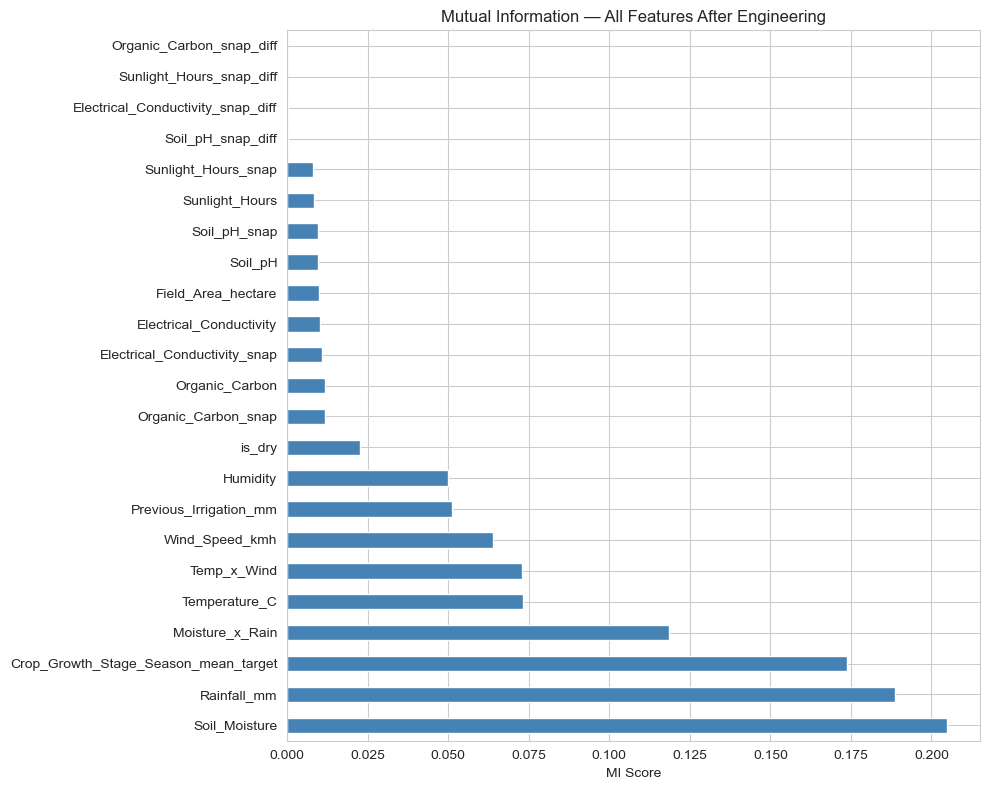

Soil_Moisture                          0.205
Rainfall_mm                            0.189
Crop_Growth_Stage_Season_mean_target   0.174
Moisture_x_Rain                        0.118
Temperature_C                          0.073
Temp_x_Wind                            0.073
Wind_Speed_kmh                         0.064
Previous_Irrigation_mm                 0.051
Humidity                               0.050
is_dry                                 0.023
Organic_Carbon_snap                    0.012
Organic_Carbon                         0.012
Electrical_Conductivity_snap           0.011
Electrical_Conductivity                0.010
Field_Area_hectare                     0.010
Soil_pH                                0.010
Soil_pH_snap                           0.010
Sunlight_Hours                         0.008
Sunlight_Hours_snap                    0.008
Soil_pH_snap_diff                      0.000
Electrical_Conductivity_snap_diff      0.000
Sunlight_Hours_snap_diff               0.000
Organic_Ca

In [45]:
from sklearn.feature_selection import mutual_info_classif

new_num_features = [
    'is_dry', 'Temp_x_Wind', 'Moisture_x_Rain',
    'Crop_Growth_Stage_Season_mean_target'
]

all_num = [c for c in df.columns if df[c].dtype in ['float64', 'int64'] 
           and c not in ['id', 'Irrigation_Need']]

mi = mutual_info_classif(df[all_num], df['Irrigation_Need'], random_state=42)
mi_series = pd.Series(mi, index=all_num).sort_values(ascending=False)

mi_series.plot(kind='barh', figsize=(10, 8), color='steelblue')
plt.title('Mutual Information — All Features After Engineering')
plt.xlabel('MI Score')
plt.tight_layout()
plt.show()
print(mi_series)

In [47]:
snap_cols_to_drop = [c for c in df.columns if '_snap' in c]
df.drop(columns=snap_cols_to_drop, inplace=True, errors='ignore')
test.drop(columns=snap_cols_to_drop, inplace=True, errors='ignore')
print("Remaining features:", [c for c in df.columns if c not in ['id', 'Irrigation_Need']])

Remaining features: ['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'is_dry', 'Temp_x_Wind', 'Moisture_x_Rain', 'Crop_Growth_Stage_Season_mean_target']


In [51]:
# Ratio features
for dataset in [train, test]:
    dataset['Moisture_div_Rain'] = dataset['Soil_Moisture'] / (dataset['Rainfall_mm'] + 1)
    dataset['Temp_div_Humidity'] = dataset['Temperature_C'] / (dataset['Humidity'] + 1)

# Check MI
new_ratio_cols = ['Moisture_div_Rain', 'Temp_div_Humidity']
mi = mutual_info_classif(train[new_ratio_cols], train['Irrigation_Need'], random_state=42)
mi_series = pd.Series(mi, index=new_ratio_cols).sort_values(ascending=False)
print(mi_series)

Moisture_div_Rain   0.101
Temp_div_Humidity   0.026
dtype: float64


In [55]:
NUMS = [
    'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
    'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
    'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm',
    'is_dry', 'Temp_x_Wind', 'Moisture_x_Rain', 'Crop_Growth_Stage_Season_mean_target'
]

NUMS += ['Moisture_div_Rain']
print("Total NUMS:", len(NUMS))

Total NUMS: 16


In [56]:
for dataset in [train, test]:
    dataset.drop(columns=['Temp_div_Humidity'], inplace=True, errors='ignore')

NUMS += ['Moisture_div_Rain']
print("Added: Moisture_div_Rain, MI=0.101")

Added: Moisture_div_Rain, MI=0.101


In [57]:
# GroupBy std and count aggregates
groupby_aggs = [
    (['Crop_Growth_Stage', 'Season'], 'Soil_Moisture', 'std'),
    (['Crop_Growth_Stage', 'Season'], 'Rainfall_mm', 'std'),
    (['Mulching_Used', 'Season'], 'Soil_Moisture', 'mean'),
    (['Irrigation_Type', 'Season'], 'Rainfall_mm', 'mean'),
]

for cols, feat, agg in groupby_aggs:
    col_name = '_'.join(cols) + f'_{feat}_{agg}'
    mapping = train.groupby(cols)[feat].agg(agg)
    train[col_name] = train.set_index(cols).index.map(mapping)
    test[col_name] = test.set_index(cols).index.map(mapping)

new_agg_cols = ['_'.join(c) + f'_{f}_{a}' for c, f, a in groupby_aggs]

mi = mutual_info_classif(train[new_agg_cols], train['Irrigation_Need'], random_state=42)
mi_series = pd.Series(mi, index=new_agg_cols).sort_values(ascending=False)
print(mi_series)

Crop_Growth_Stage_Season_Rainfall_mm_std     0.176
Crop_Growth_Stage_Season_Soil_Moisture_std   0.173
Mulching_Used_Season_Soil_Moisture_mean      0.058
Irrigation_Type_Season_Rainfall_mm_mean      0.007
dtype: float64


In [58]:
for dataset in [train, test]:
    dataset.drop(columns=['Irrigation_Type_Season_Rainfall_mm_mean'], inplace=True, errors='ignore')

NUMS += [
    'Crop_Growth_Stage_Season_Rainfall_mm_std',
    'Crop_Growth_Stage_Season_Soil_Moisture_std',
    'Mulching_Used_Season_Soil_Moisture_mean'
]
print("Total NUMS:", len(NUMS))

Total NUMS: 20


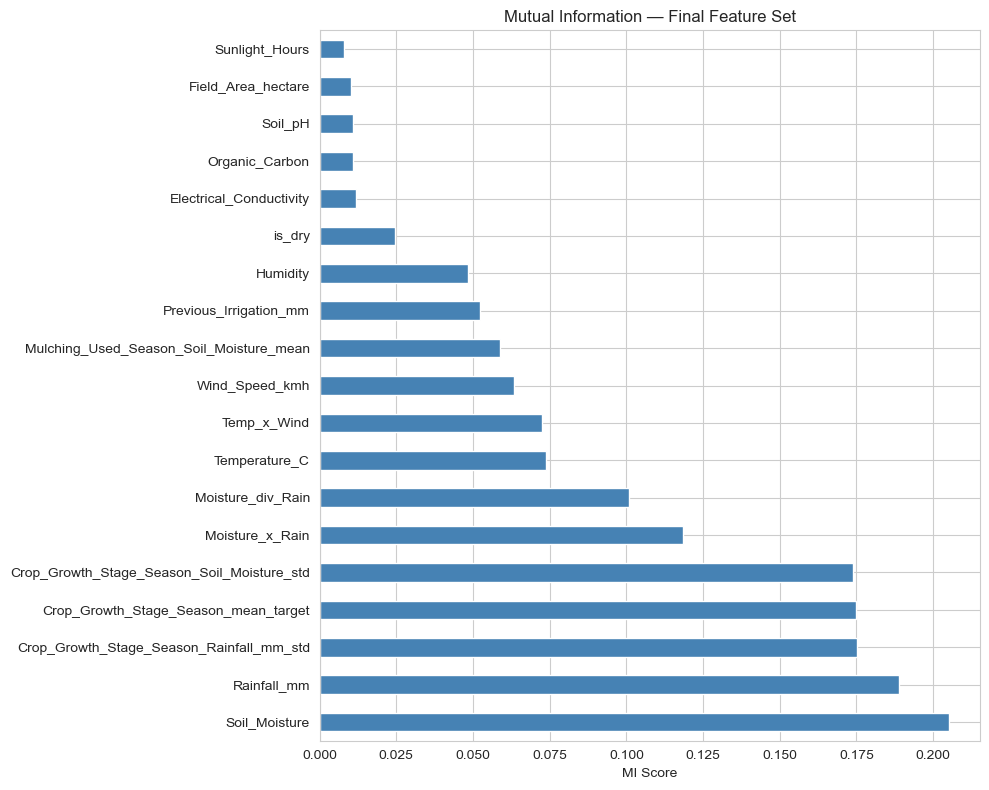

Soil_Moisture                                0.205
Rainfall_mm                                  0.189
Crop_Growth_Stage_Season_Rainfall_mm_std     0.175
Crop_Growth_Stage_Season_mean_target         0.175
Crop_Growth_Stage_Season_Soil_Moisture_std   0.174
Moisture_x_Rain                              0.118
Moisture_div_Rain                            0.101
Temperature_C                                0.074
Temp_x_Wind                                  0.073
Wind_Speed_kmh                               0.063
Mulching_Used_Season_Soil_Moisture_mean      0.059
Previous_Irrigation_mm                       0.052
Humidity                                     0.048
is_dry                                       0.024
Electrical_Conductivity                      0.012
Organic_Carbon                               0.011
Soil_pH                                      0.011
Field_Area_hectare                           0.010
Sunlight_Hours                               0.008
dtype: float64


In [62]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['Irrigation_Need_encoded'] = le.fit_transform(train['Irrigation_Need'])

for dataset in [train, test]:
    dataset['is_dry'] = (dataset['Rainfall_mm'] < 500).astype(int)
    dataset['Temp_x_Wind'] = dataset['Temperature_C'] * dataset['Wind_Speed_kmh']
    dataset['Moisture_x_Rain'] = dataset['Soil_Moisture'] * dataset['Rainfall_mm']
    dataset['Moisture_div_Rain'] = dataset['Soil_Moisture'] / (dataset['Rainfall_mm'] + 1)

mapping1 = train.groupby(['Crop_Growth_Stage', 'Season'])['Irrigation_Need_encoded'].mean()
train['Crop_Growth_Stage_Season_mean_target'] = train.set_index(['Crop_Growth_Stage', 'Season']).index.map(mapping1)
test['Crop_Growth_Stage_Season_mean_target'] = test.set_index(['Crop_Growth_Stage', 'Season']).index.map(mapping1)

mapping2 = train.groupby(['Crop_Growth_Stage', 'Season'])['Rainfall_mm'].std()
train['Crop_Growth_Stage_Season_Rainfall_mm_std'] = train.set_index(['Crop_Growth_Stage', 'Season']).index.map(mapping2)
test['Crop_Growth_Stage_Season_Rainfall_mm_std'] = test.set_index(['Crop_Growth_Stage', 'Season']).index.map(mapping2)

mapping3 = train.groupby(['Crop_Growth_Stage', 'Season'])['Soil_Moisture'].std()
train['Crop_Growth_Stage_Season_Soil_Moisture_std'] = train.set_index(['Crop_Growth_Stage', 'Season']).index.map(mapping3)
test['Crop_Growth_Stage_Season_Soil_Moisture_std'] = test.set_index(['Crop_Growth_Stage', 'Season']).index.map(mapping3)

mapping4 = train.groupby(['Mulching_Used', 'Season'])['Soil_Moisture'].mean()
train['Mulching_Used_Season_Soil_Moisture_mean'] = train.set_index(['Mulching_Used', 'Season']).index.map(mapping4)
test['Mulching_Used_Season_Soil_Moisture_mean'] = test.set_index(['Mulching_Used', 'Season']).index.map(mapping4)

NUMS = [
    'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
    'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
    'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm',
    'is_dry', 'Temp_x_Wind', 'Moisture_x_Rain', 'Moisture_div_Rain',
    'Crop_Growth_Stage_Season_mean_target',
    'Crop_Growth_Stage_Season_Rainfall_mm_std',
    'Crop_Growth_Stage_Season_Soil_Moisture_std',
    'Mulching_Used_Season_Soil_Moisture_mean'
]

mi = mutual_info_classif(train[NUMS], train['Irrigation_Need_encoded'], random_state=42)
mi_series = pd.Series(mi, index=NUMS).sort_values(ascending=False)

mi_series.plot(kind='barh', figsize=(10, 8), color='steelblue')
plt.title('Mutual Information — Final Feature Set')
plt.xlabel('MI Score')
plt.tight_layout()
plt.show()
print(mi_series)